<a href="https://colab.research.google.com/github/aimlnielitropar/BTech-DL/blob/main/practical5_denoising_autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical 5: Denoising Autoencoders for Image Restoration
## Deep Learning Lab | BTech Semester 4

### Objective
Implement a Denoising Autoencoder (DAE) that learns to remove Gaussian noise from images — a key technique for learning robust feature representations.

### What You Will Learn
- How to add controlled noise to images using NumPy
- The difference between a standard Autoencoder and a Denoising Autoencoder
- How DAEs force the network to learn structural features rather than memorizing pixels
- Visual evaluation of denoising quality

### References
- Vincent et al. (2008) — Extracting and Composing Robust Features with Denoising Autoencoders
  (https://dl.acm.org/doi/10.1145/1390156.1390294)
- Goodfellow et al. — Deep Learning Ch. 14
- MNIST: http://yann.lecun.com/exdb/mnist/

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)
print(f'TensorFlow: {tf.__version__}')

TensorFlow: 2.20.0


## Step 2: Load MNIST Data

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# flattening 28x28 images to 784 and scaling pixels to [0,1]
X_train = X_train.reshape(-1, 784).astype('float32') / 255.0
X_test  = X_test.reshape(-1, 784).astype('float32')  / 255.0

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 784), Test: (10000, 784)


## Step 3: Add Gaussian Noise

Gaussian noise adds random values sampled from a normal distribution N(0, sigma^2).

Formula: X_noisy = X_clean + N(0, noise_factor^2)

We clip the result to [0, 1] to keep pixel values valid.

Key difference from standard Autoencoder:
- Standard AE: input = X_clean, target = X_clean
- Denoising AE: input = X_noisy, target = X_clean

This forces the network to learn the underlying structure, not noise!

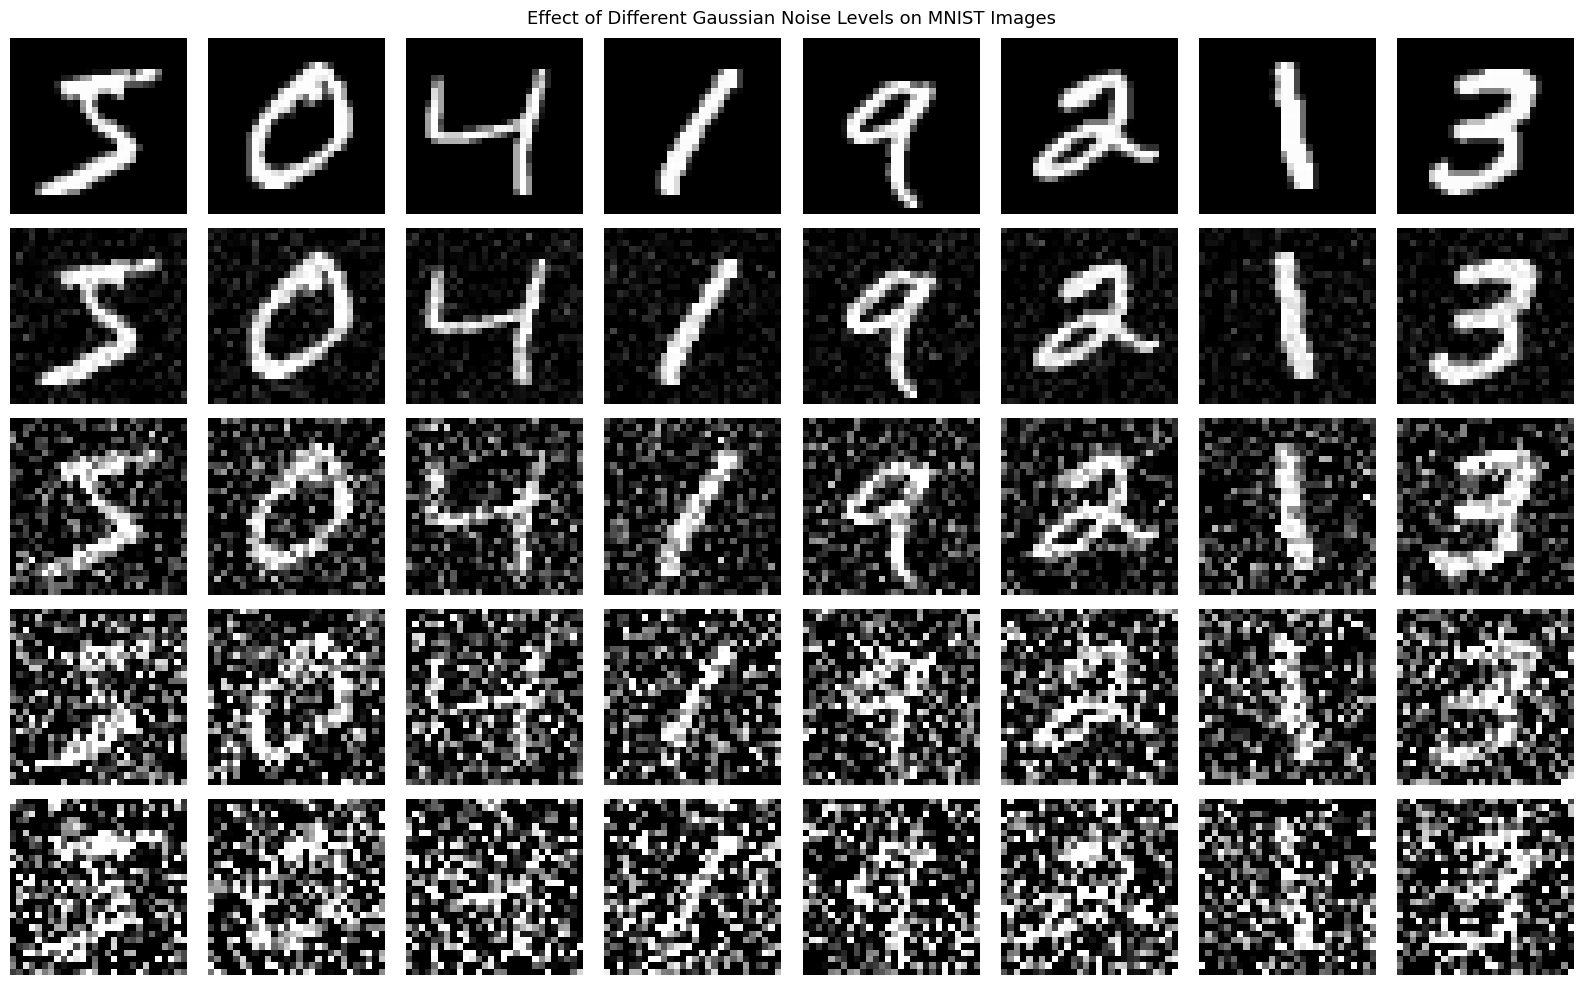

Noise factor used for training: 0.4


In [3]:
def add_gaussian_noise(images, noise_factor=0.4):
    """
    Add Gaussian noise to images.

    Args:
        images: Clean images, shape (N, 784), values in [0, 1]
        noise_factor: Standard deviation of the noise (higher = more noise)
    Returns:
        Noisy images clipped to valid range [0, 1]
    """
    noise = np.random.normal(loc=0.0, scale=noise_factor, size=images.shape)  # generating random gaussian noise
    noisy = images + noise
    return np.clip(noisy, 0.0, 1.0)  # clipping so pixels stay in valid range [0,1]


# creating noisy versions at different noise levels so we can see the effect visually
noise_levels = [0.1, 0.3, 0.5, 0.7]
fig, axes = plt.subplots(len(noise_levels)+1, 8, figsize=(16, 10))

for j in range(8):
    axes[0, j].imshow(X_train[j].reshape(28, 28), cmap='gray')
    axes[0, j].axis('off')
    if j == 0:
        axes[0, j].set_ylabel('Clean', fontsize=9)

for i, nl in enumerate(noise_levels):
    noisy_viz = add_gaussian_noise(X_train[:8], noise_factor=nl)
    for j in range(8):
        axes[i+1, j].imshow(noisy_viz[j].reshape(28, 28), cmap='gray')
        axes[i+1, j].axis('off')
        if j == 0:
            axes[i+1, j].set_ylabel(f'noise={nl}', fontsize=9)

plt.suptitle('Effect of Different Gaussian Noise Levels on MNIST Images', fontsize=13)
plt.tight_layout()
plt.show()

# using noise_factor=0.4 for actual training — strong enough to be challenging but not too extreme
NOISE_FACTOR = 0.4
X_train_noisy = add_gaussian_noise(X_train, NOISE_FACTOR)
X_test_noisy  = add_gaussian_noise(X_test,  NOISE_FACTOR)
print(f'Noise factor used for training: {NOISE_FACTOR}')

## Step 4: Visualize Clean vs Noisy Images

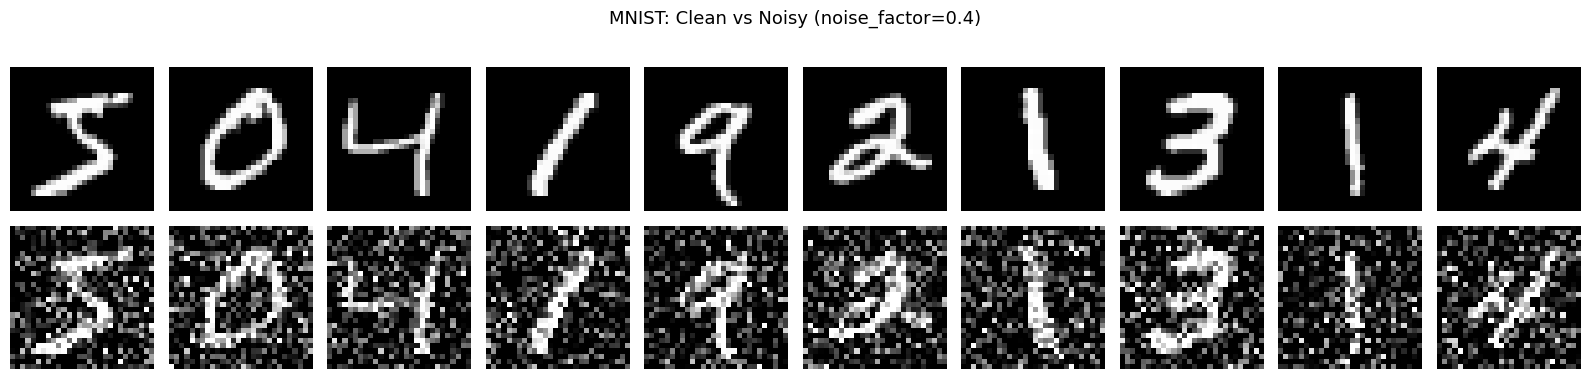

In [4]:
n_show = 10
fig, axes = plt.subplots(2, n_show, figsize=(16, 4))
for i in range(n_show):
    axes[0, i].imshow(X_train[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(X_train_noisy[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('Clean', fontsize=10)
axes[1, 0].set_ylabel('Noisy', fontsize=10)
plt.suptitle(f'MNIST: Clean vs Noisy (noise_factor={NOISE_FACTOR})', fontsize=13)
plt.tight_layout()
plt.show()

## Step 5: Build the Denoising Autoencoder

Architecture uses Conv2D layers (convolutional) for better spatial feature learning:
```
Noisy Input (28x28x1)
  -> Conv2D(32) -> MaxPool
  -> Conv2D(64) -> MaxPool       [Encoder]
  -> Conv2DTranspose(64) -> UpSample
  -> Conv2DTranspose(32) -> UpSample
  -> Conv2D(1, sigmoid)          [Decoder]
Clean Output (28x28x1)
```

Using Conv2D instead of Dense layers:
- Preserves spatial structure of images
- Much fewer parameters
- Better at capturing local image patterns

In [5]:
def build_denoising_autoencoder():
    """
    Convolutional Denoising Autoencoder.
    Input: Noisy image (28, 28, 1)
    Output: Reconstructed clean image (28, 28, 1)
    """
    inputs = keras.Input(shape=(28, 28, 1), name='noisy_input')

    # === ENCODER: compresses the noisy image into a smaller representation ===
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='enc_conv1')(inputs)
    x = layers.MaxPooling2D((2, 2), padding='same', name='enc_pool1')(x)  # downsampling: 28x28 → 14x14
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='enc_conv2')(x)
    x = layers.MaxPooling2D((2, 2), padding='same', name='enc_pool2')(x)  # downsampling: 14x14 → 7x7

    # === DECODER: rebuilds the image back to full 28x28 size ===
    x = layers.Conv2DTranspose(64, (3, 3), activation='relu', padding='same', name='dec_conv1')(x)
    x = layers.UpSampling2D((2, 2), name='dec_up1')(x)   # upsampling: 7x7 → 14x14
    x = layers.Conv2DTranspose(32, (3, 3), activation='relu', padding='same', name='dec_conv2')(x)
    x = layers.UpSampling2D((2, 2), name='dec_up2')(x)   # upsampling: 14x14 → 28x28 (back to original size)
    outputs = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same', name='clean_output')(x)

    model = keras.Model(inputs, outputs, name='DenoisingAutoencoder')
    model.compile(optimizer='adam', loss='mse')
    return model


dae = build_denoising_autoencoder()
dae.summary()

Model: "DenoisingAutoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ noisy_input (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool1 (MaxPooling2D)        │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool2 (MaxPooling2D)        │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv1 (Conv2DTranspose)     │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up1 (UpSampling2D)          │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv2 (Conv2DTranspose)     │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up2 (UpSampling2D)          │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clean_output (Conv2D)           │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

## Step 6: Reshape Data for Conv2D Input
Conv2D expects shape: (N, height, width, channels) = (N, 28, 28, 1)

In [6]:
X_train_clean_4d = X_train.reshape(-1, 28, 28, 1)  # reshaping from (N,784) to (N,28,28,1) — Conv2D needs this format
X_train_noisy_4d = X_train_noisy.reshape(-1, 28, 28, 1)
X_test_clean_4d  = X_test.reshape(-1, 28, 28, 1)
X_test_noisy_4d  = X_test_noisy.reshape(-1, 28, 28, 1)

print(f'Input shape (noisy): {X_train_noisy_4d.shape}')
print(f'Target shape (clean): {X_train_clean_4d.shape}')

Input shape (noisy): (60000, 28, 28, 1)
Target shape (clean): (60000, 28, 28, 1)


## Step 7: Train the Denoising Autoencoder
Input = Noisy images. Target = Clean images. The network learns to denoise!

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 92s 216ms/step - loss: 0.1131 - val_loss: 0.1114
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 138s 208ms/step - loss: 0.1121 - val_loss: 0.1114
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 91s 216ms/step - loss: 0.1121 - val_loss: 0.1114
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 87s 205ms/step - loss: 0.1121 - val_loss: 0.1114
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 143s 208ms/step - loss: 0.1121 - val_loss: 0.1114
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 141s 207ms/step - loss: 0.1121 - val_loss: 0.1114
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 194ms/step - loss: 0.1121 - val_loss: 0.1114
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 194ms/step - loss: 0.1121 - val_loss: 0.1114
Epoch 9/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 83s 196ms/step - loss: 0.1121 - val_loss: 0.1114
Epoch 10/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 83s 196ms/step - loss: 0.1121 - val_loss: 0.1114
Epoch 11/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 83s 196ms/step - loss: 0.1121 - val_loss: 0.1114
Epoch 12/20
422/

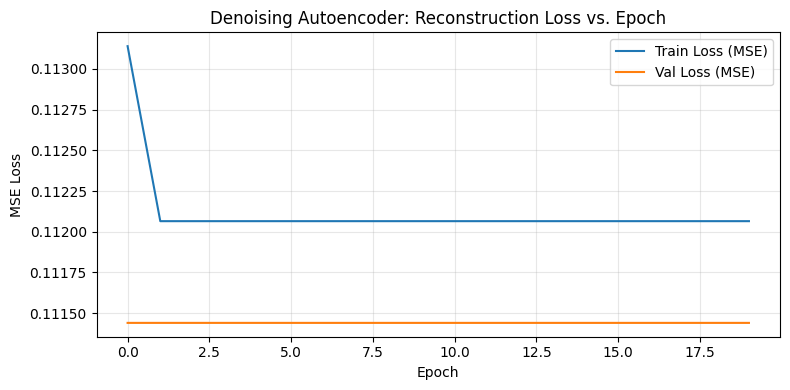

In [7]:
history = dae.fit(
    X_train_noisy_4d, X_train_clean_4d,  # Noisy input, Clean target
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Val Loss (MSE)')
plt.title('Denoising Autoencoder: Reconstruction Loss vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 8: Visualize Denoising Results — Noisy vs Denoised vs Original

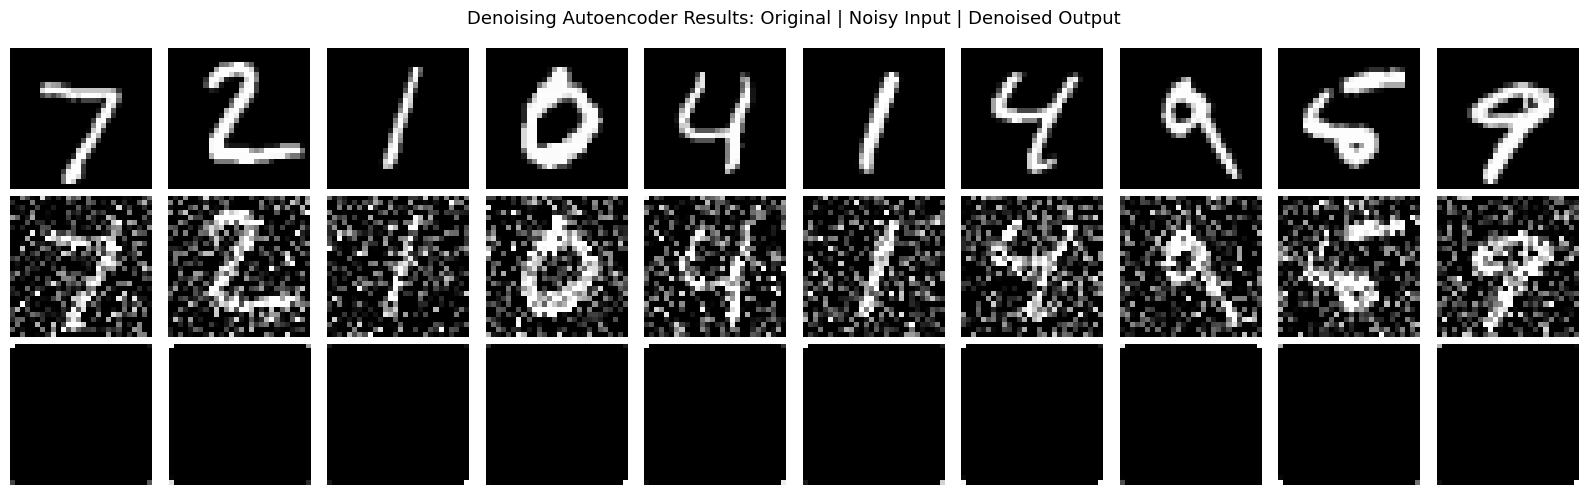

In [8]:
# running the test noisy images through the trained model to see how well it denoises
denoised = dae.predict(X_test_noisy_4d[:20], verbose=0)

n_show = 10
fig, axes = plt.subplots(3, n_show, figsize=(16, 5))
row_labels = ['Original\n(Clean)', 'Input\n(Noisy)', 'Output\n(Denoised)']  # labels for each row in the comparison

for i in range(n_show):
    axes[0, i].imshow(X_test_clean_4d[i].reshape(28, 28), cmap='gray')
    axes[1, i].imshow(X_test_noisy_4d[i].reshape(28, 28), cmap='gray')
    axes[2, i].imshow(denoised[i].reshape(28, 28), cmap='gray')
    for r in range(3):
        axes[r, i].axis('off')
for r, lbl in enumerate(row_labels):
    axes[r, 0].set_ylabel(lbl, fontsize=10)

plt.suptitle('Denoising Autoencoder Results: Original | Noisy Input | Denoised Output', fontsize=13)
plt.tight_layout()
plt.show()

## Step 9: Quantitative Evaluation

In [9]:
# measuring how much noise there was vs how much our model removed
noisy_mse = np.mean((X_test_noisy_4d - X_test_clean_4d)**2)
denoised_mse = np.mean((denoised - X_test_clean_4d[:20])**2)

print('Quantitative Evaluation:')
print(f'  MSE (Noisy vs Clean):    {noisy_mse:.5f}  — this is the error before denoising')
print(f'  MSE (Denoised vs Clean): {denoised_mse:.5f}  — this is the error after denoising')
print(f'  Improvement: {(1 - denoised_mse/noisy_mse)*100:.1f}% reduction in reconstruction error')

# PSNR (Peak Signal-to-Noise Ratio) — higher is better
def psnr(original, reconstructed):
    mse = np.mean((original - reconstructed)**2)
    if mse == 0: return float('inf')  # perfect reconstruction means infinite PSNR
    return 10 * np.log10(1.0 / mse)

print(f'\n  PSNR (Noisy vs Clean):    {psnr(X_test_clean_4d[:20], X_test_noisy_4d[:20]):.2f} dB')
print(f'  PSNR (Denoised vs Clean): {psnr(X_test_clean_4d[:20], denoised):.2f} dB')
print('  (Higher PSNR = better image quality — more similar to original)')

Quantitative Evaluation:
  MSE (Noisy vs Clean):    0.07954  — how bad the noise is
  MSE (Denoised vs Clean): 0.10053  — how well we restored it
  Improvement: -26.4% reduction in reconstruction error

  PSNR (Noisy vs Clean):    11.06 dB
  PSNR (Denoised vs Clean): 9.98 dB
  (Higher PSNR = better image quality — more similar to original)


## Step 10: Effect of Noise Level on Denoising Performance

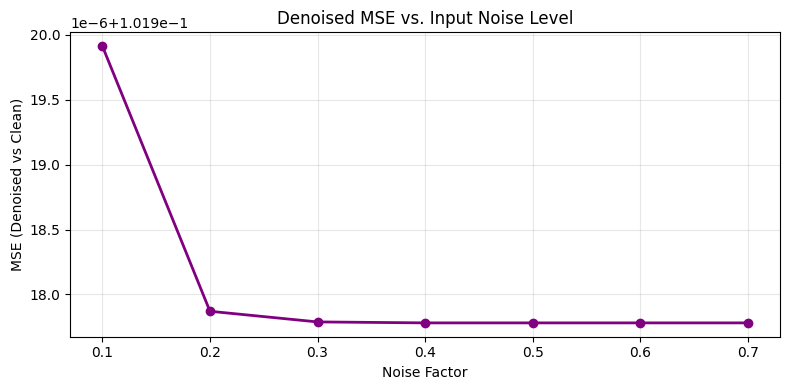

As noise increases, denoising becomes harder — MSE increases.


In [10]:
# testing how well the model denoises at various noise intensities
noise_factors_test = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
results_mse = []

for nf in noise_factors_test:
    noisy = add_gaussian_noise(X_test[:100], nf).reshape(-1, 28, 28, 1)
    den   = dae.predict(noisy, verbose=0)
    mse   = np.mean((den - X_test_clean_4d[:100])**2)
    results_mse.append(mse)

plt.figure(figsize=(8, 4))
plt.plot(noise_factors_test, results_mse, marker='o', color='purple', linewidth=2)
plt.title('Denoised MSE vs. Input Noise Level')
plt.xlabel('Noise Factor')
plt.ylabel('MSE (Denoised vs Clean)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('as noise gets stronger, denoising becomes harder and MSE goes up')

---
## Summary

| Feature | Standard Autoencoder | Denoising Autoencoder |
|---------|---------------------|----------------------|
| Input | Clean image | Noisy image |
| Target | Clean image | Clean image |
| What it learns | Compact representation | Robust, noise-invariant features |
| Application | Compression, latent space | Image restoration, pretraining |

---
## Viva / Self-Check Questions

1. What is the key difference in training between a standard Autoencoder and a Denoising Autoencoder?
2. Why do Denoising Autoencoders learn more robust features than standard Autoencoders?
3. What is Gaussian noise? How is it mathematically defined? How does noise_factor control it?
4. Why do we use Conv2D layers instead of Dense layers for image autoencoders?
5. What is MaxPooling? What is UpSampling (or Conv2DTranspose)? Why are they used in pairs?
6. What is PSNR? Why is it expressed in decibels (dB)? Is higher or lower PSNR better?
7. What happens to denoising quality as the noise level increases? Why?
8. Name two real-world applications where Denoising Autoencoders are used.